In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Amber benchmark CAMI II marine pooled

* Source: https://usegalaxy.eu/u/paulzierep/h/copy-of-fairymags-taxonomic-binning-evaluation-pooled

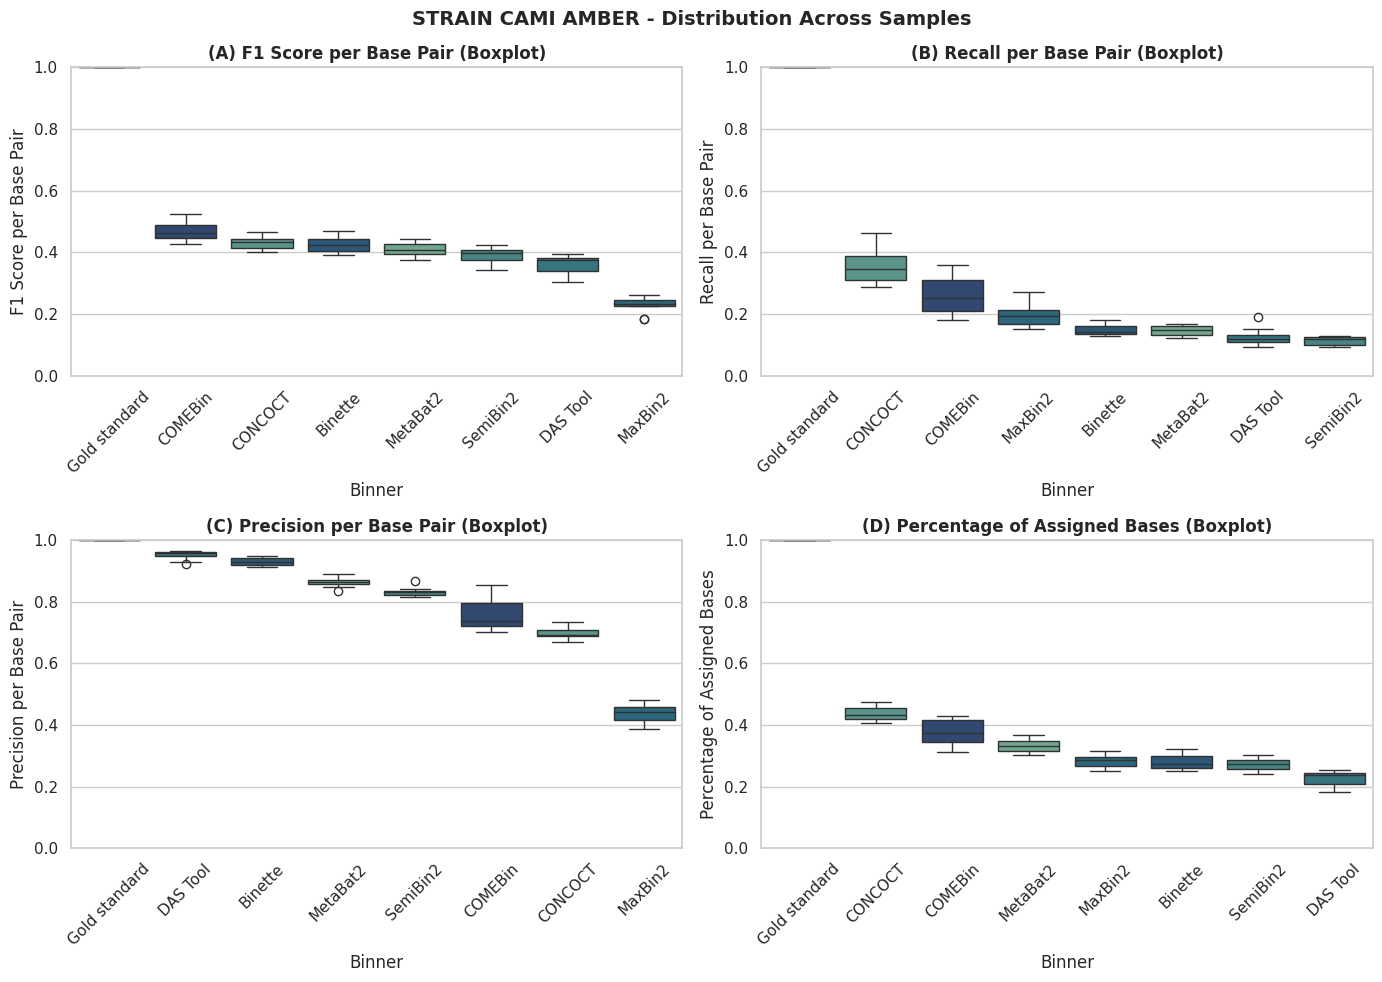

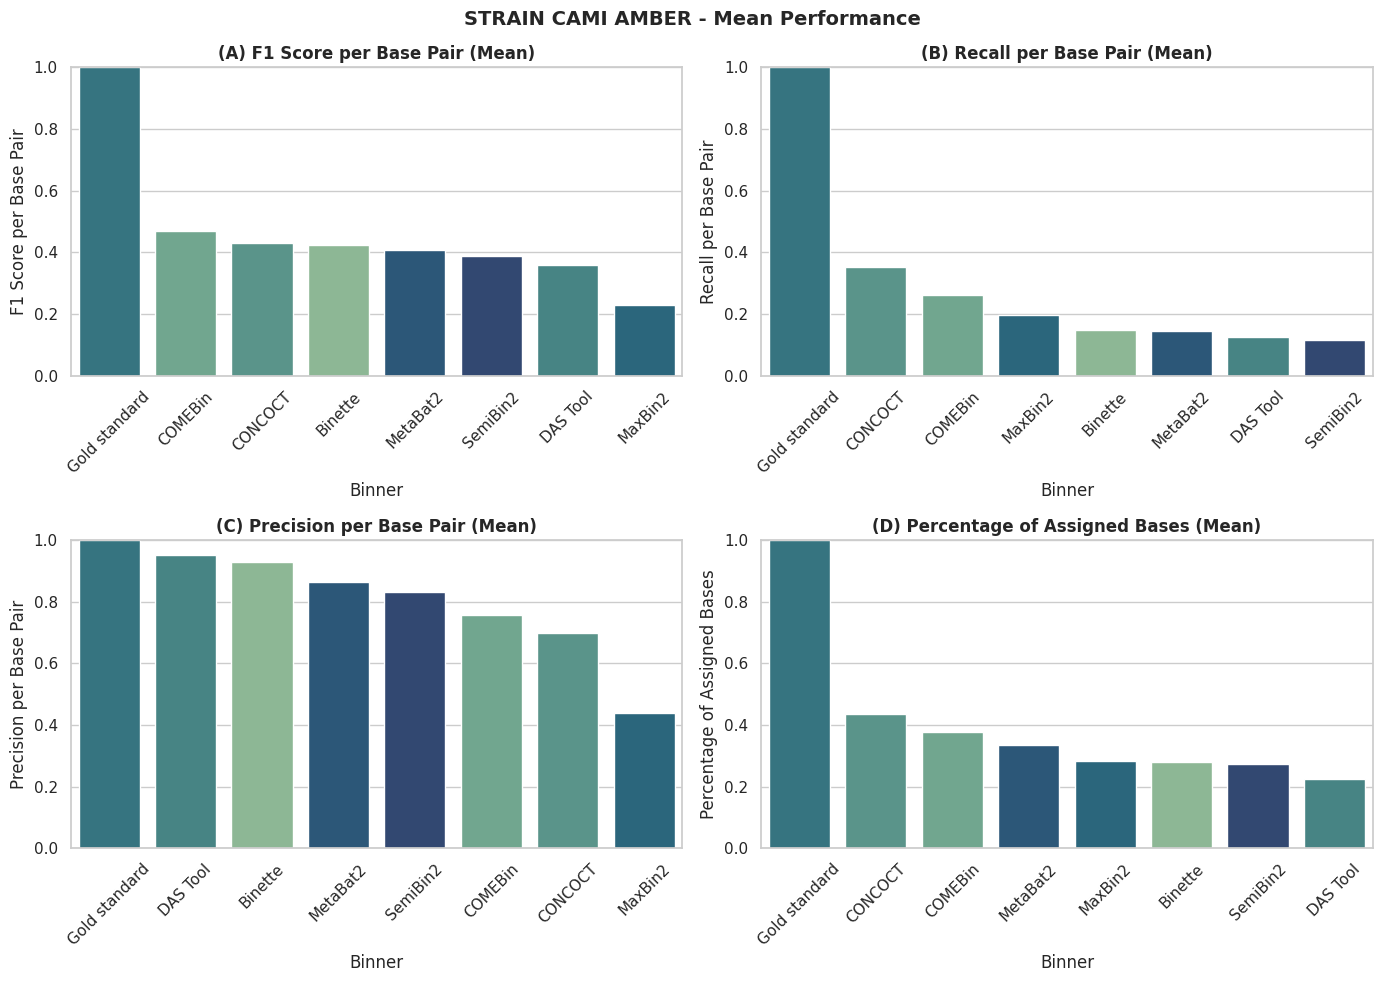

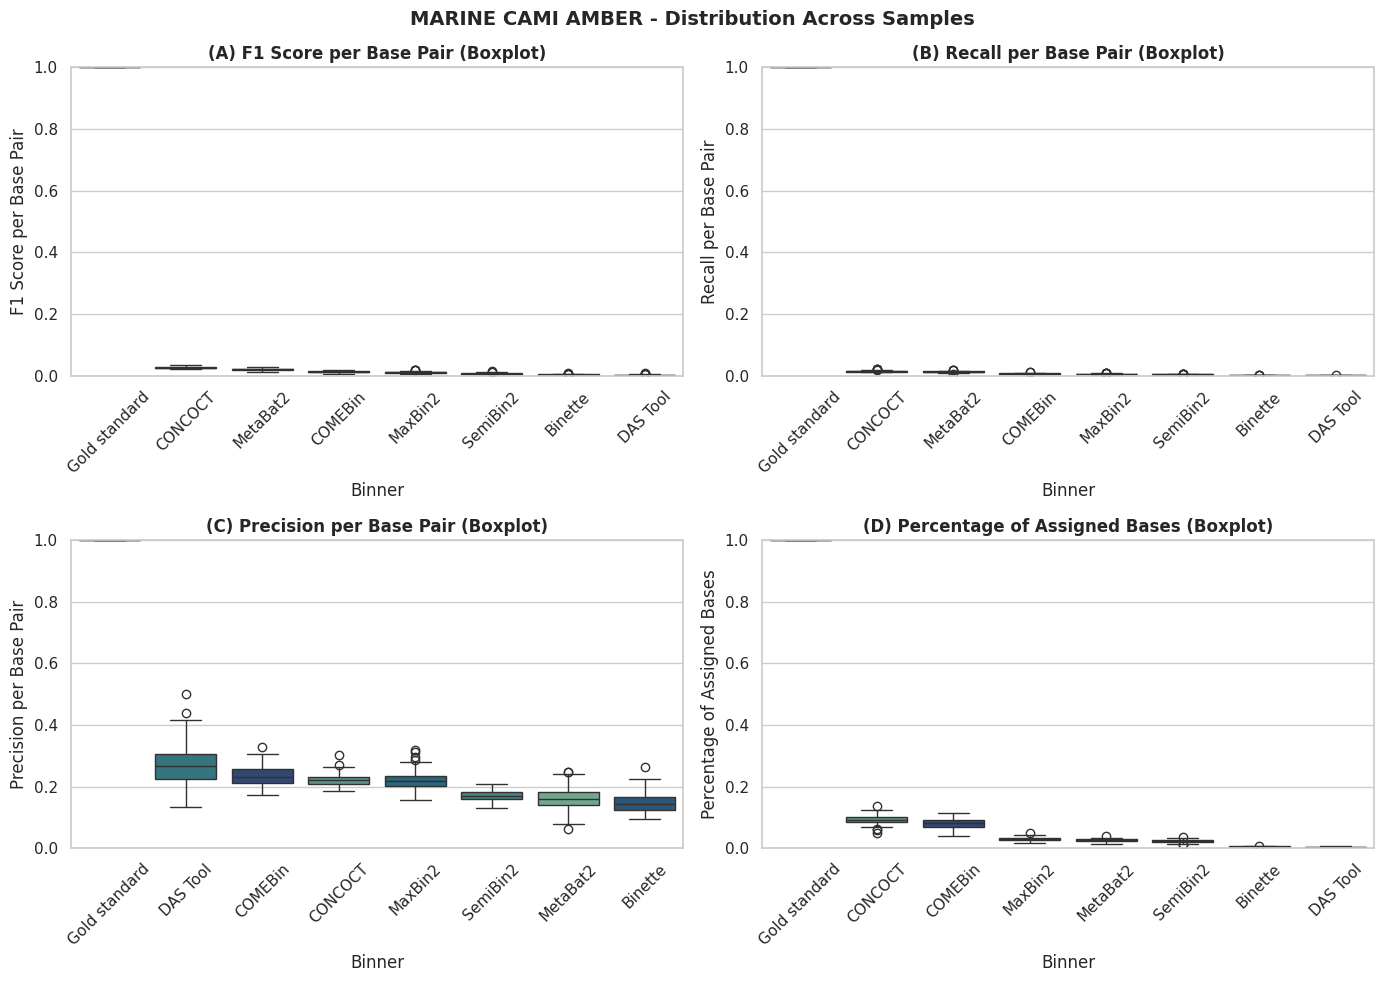

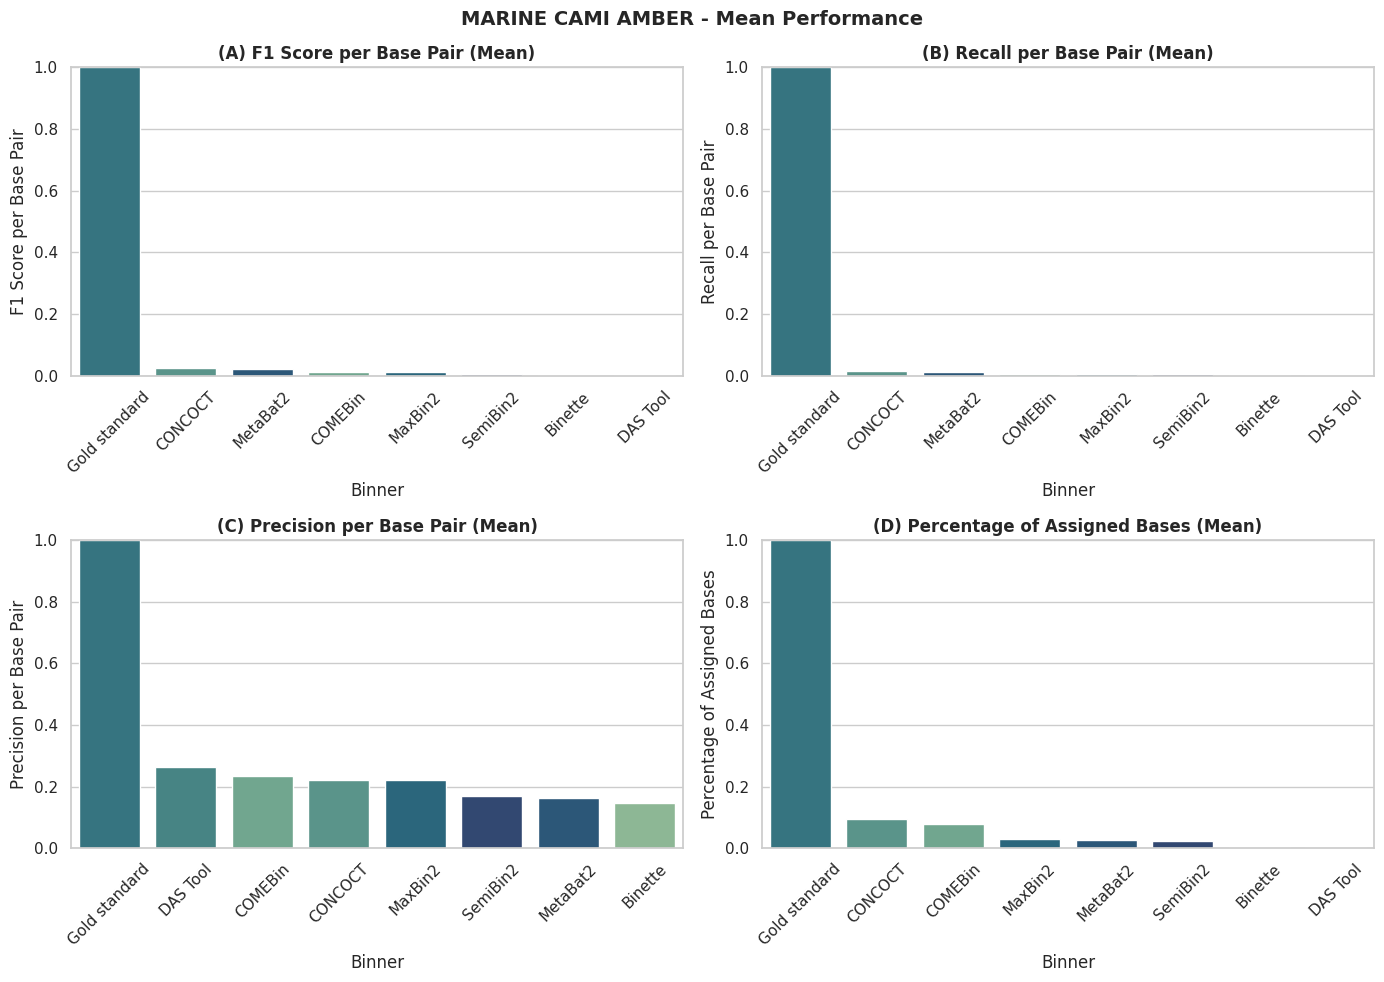

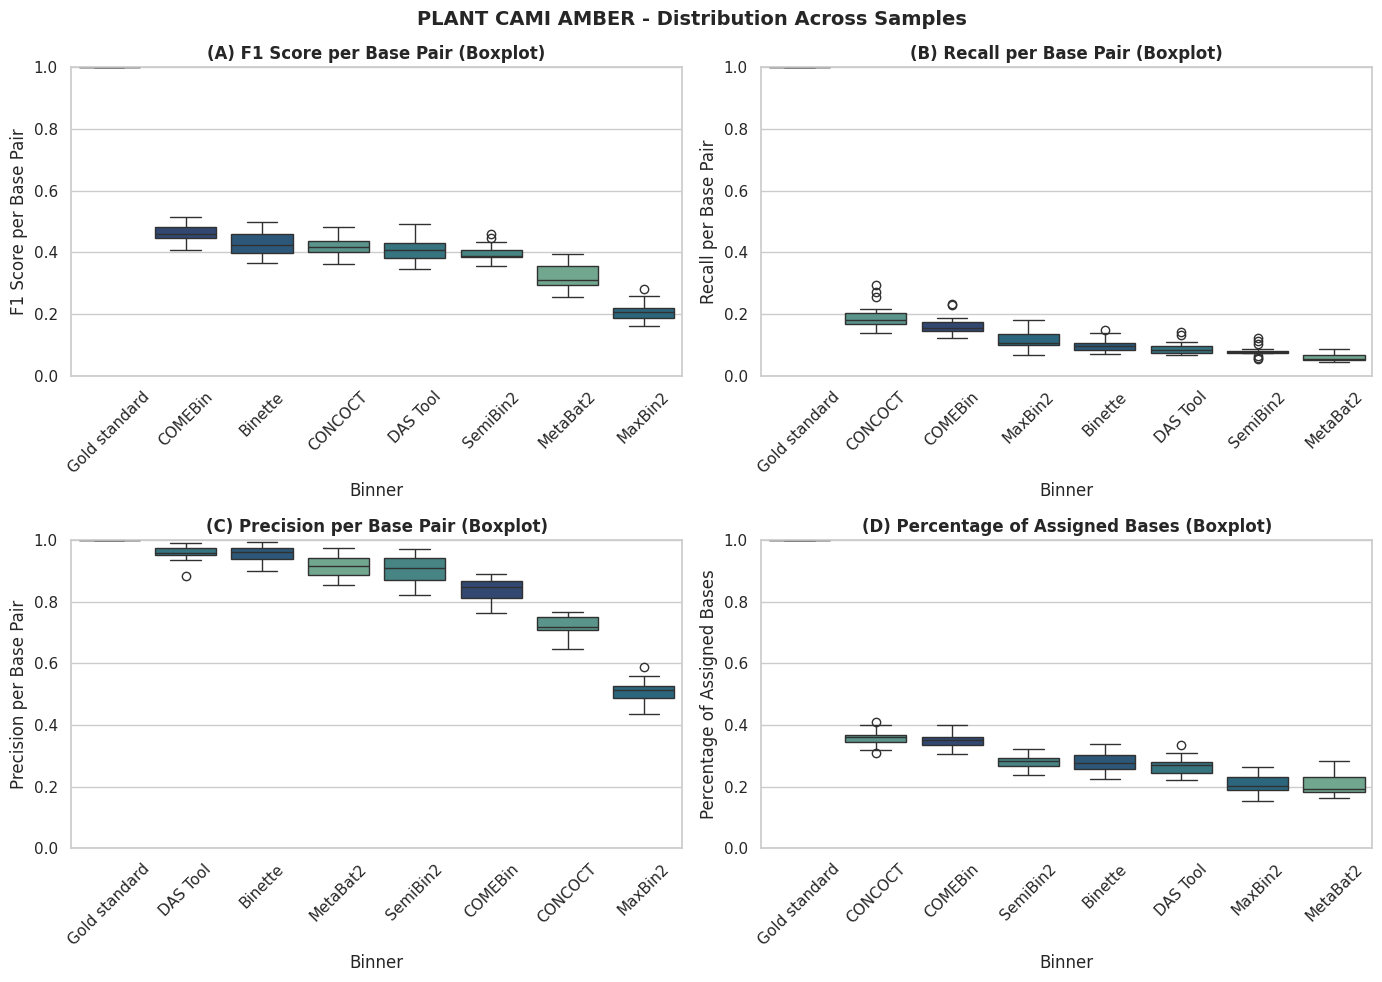

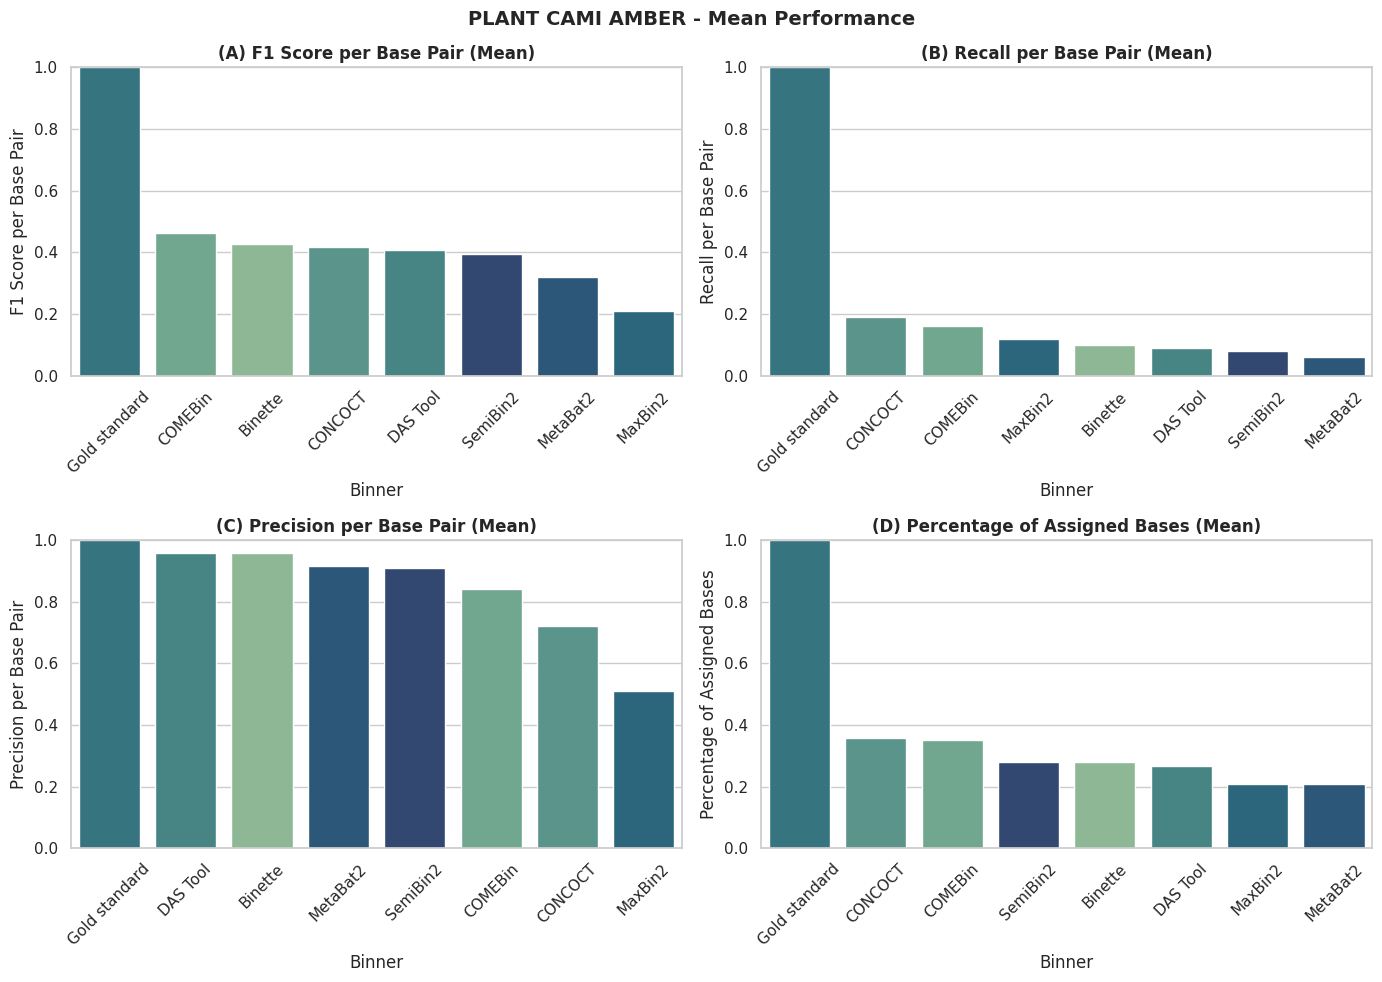

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

input_dir = "input"
output_dir = "plots"
os.makedirs(output_dir, exist_ok=True)

sns.set(style="whitegrid")

metrics = [
    ('f1_score_per_bp', 'F1 Score per Base Pair', '(A)'),
    ('recall_avg_bp', 'Recall per Base Pair', '(B)'),
    ('precision_avg_bp', 'Precision per Base Pair', '(C)'),
    ('percentage_of_assigned_bps', 'Percentage of Assigned Bases', '(D)')
]


def load_data(filepath):
    df = pd.read_csv(filepath, sep="\t", index_col="Sample")
    df = df[df["binning type"] == "genome"].reset_index()
    return df


def get_order(df, col):
    means = df.groupby("Tool")[col].mean().reset_index()
    return means.sort_values(col, ascending=False)["Tool"]


def plot_boxplots(df, dataset):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.subplots_adjust(hspace=0.35, wspace=0.3)

    for ax, (col, ylabel, label) in zip(axes.flatten(), metrics):

        order = get_order(df, col)

        sns.boxplot(
            data=df,
            x="Tool",
            y=col,
            hue="Tool",
            order=order,
            palette="crest",
            dodge=False,
            legend=False,
            ax=ax
        )
        ax.set_ylim(0, 1)
        ax.set_title(f'{label} {ylabel} (Boxplot)', fontsize=12, weight='bold')
        ax.set_xlabel('Binner')
        ax.set_ylabel(ylabel)
        ax.tick_params(axis='x', rotation=45)

    plt.suptitle(f"{dataset.upper()} CAMI AMBER - Distribution Across Samples",
                 fontsize=14, weight="bold")

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{dataset}_boxplots.png"), dpi=300)
    plt.show()


def plot_means(df, dataset):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.subplots_adjust(hspace=0.35, wspace=0.3)

    for ax, (col, ylabel, label) in zip(axes.flatten(), metrics):

        means = df.groupby("Tool")[col].mean().reset_index()
        order = means.sort_values(col, ascending=False)["Tool"]

        sns.barplot(
            data=means,
            x="Tool",
            y=col,
            hue="Tool",
            order=order,
            palette="crest",
            dodge=False,
            legend=False,
            ax=ax
        )
        ax.set_ylim(0, 1)
        ax.set_title(f'{label} {ylabel} (Mean)', fontsize=12, weight='bold')
        ax.set_xlabel('Binner')
        ax.set_ylabel(ylabel)
        ax.tick_params(axis='x', rotation=45)

    plt.suptitle(f"{dataset.upper()} CAMI AMBER - Mean Performance",
                 fontsize=14, weight="bold")

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{dataset}_means.png"), dpi=300)
    plt.show()


def process_file(filepath):
    filename = os.path.basename(filepath)
    dataset = filename.replace("cami_amber_", "").replace(".tsv", "")

    df = load_data(filepath)

    plot_boxplots(df, dataset)
    plot_means(df, dataset)


for file in os.listdir(input_dir):
    if file.startswith("cami_amber_") and file.endswith(".tsv"):
        process_file(os.path.join(input_dir, file))

# Cami II marine

* Source: https://usegalaxy.eu/u/paulzierep/h/mags-individual-workflow-cami-ii-marine-dataset

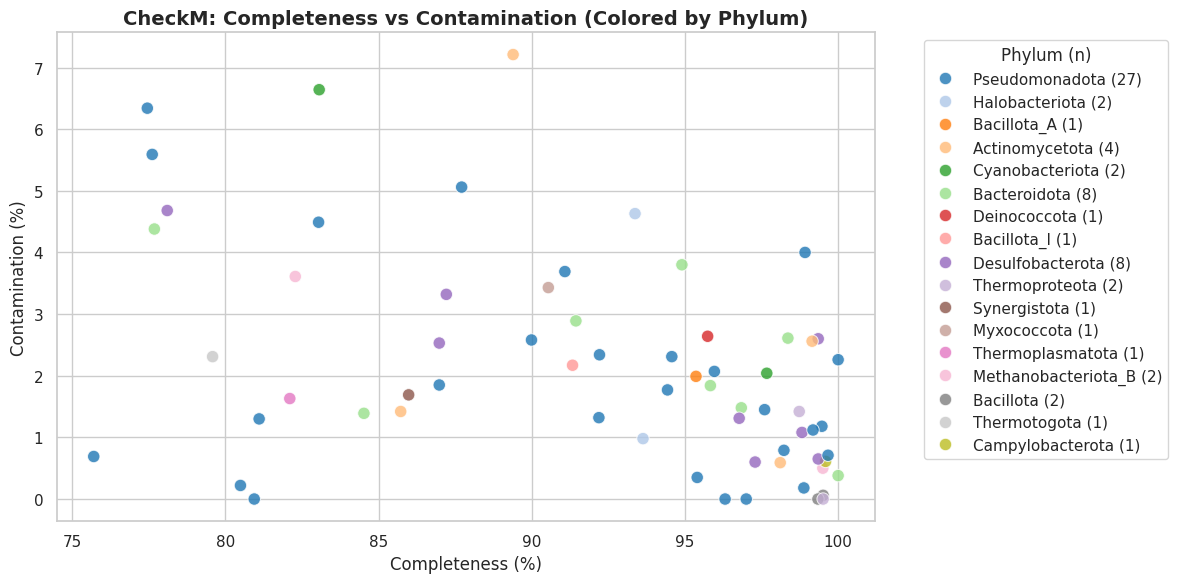

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---- URLs to the TSV files ----
checkm_results = "https://usegalaxy.eu/api/datasets/4838ba20a6d8676580958701afa6c026/display?to_ext=tabular"
gtdb_results_ar = "https://usegalaxy.eu/api/datasets/4838ba20a6d86765209d6215ad7ef1ea/display?to_ext=tsv"
gtdb_results_bac = "https://usegalaxy.eu/api/datasets/4838ba20a6d86765752584718e899bc9/display?to_ext=tsv"

# ---- Load datasets with index ----
checkm_df = pd.read_csv(checkm_results, sep='\t', index_col="Bin Id")
gtdb_ar = pd.read_csv(gtdb_results_ar, sep='\t', index_col="user_genome")
gtdb_bac = pd.read_csv(gtdb_results_bac, sep='\t', index_col="user_genome")

# ---- Fix CheckM index to match GTDB style ----
checkm_df.index = checkm_df.index.str.replace('.', '_', regex=False)

# ---- Combine archaeal and bacterial GTDB results ----
gtdb_df = pd.concat([gtdb_ar, gtdb_bac], ignore_index=False)

# ---- Extract phylum from classification column ----
def extract_phylum(classification):
    try:
        return next(x for x in classification.split(';') if x.startswith('p__')).replace('p__', '').strip()
    except StopIteration:
        return None

gtdb_df['Phylum'] = gtdb_df['classification'].apply(extract_phylum)

# ---- Join GTDB phylum into CheckM based on index ----
merged_df = checkm_df.join(gtdb_df[['Phylum']])

# ---- Create a "Phylum (n)" column for labeling ----
phylum_counts = merged_df['Phylum'].value_counts()
merged_df['Phylum (n)'] = merged_df['Phylum'].map(lambda p: f"{p} ({phylum_counts[p]})" if pd.notnull(p) else "Unknown")

# ---- Plot: Completeness vs Contamination with counts in legend ----
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=merged_df,
    y='Contamination',
    x='Completeness',
    hue='Phylum (n)',
    palette='tab20',
    s=80,
    alpha=0.8
)

plt.title('CheckM: Completeness vs Contamination (Colored by Phylum)', fontsize=14, weight='bold')
plt.ylabel('Contamination (%)')
plt.xlabel('Completeness (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Phylum (n)')
plt.tight_layout()
plt.show()
